In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
url="https://raw.githubusercontent.com/ybifoundation/Dataset/main/Salary%20Data.csv"
df=pd.read_csv(url)
df.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


In [4]:
df.shape

(40, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience Years  40 non-null     float64
 1   Salary            40 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 772.0 bytes


In [6]:
df.describe()

,Experience Years,Salary
count,40.000000,40.000000
mean,5.152500,74743.625000
std,2.663715,25947.122885
min,1.100000,37731.000000
25%,3.200000,56878.250000
50%,4.600000,64472.500000
75%,6.875000,95023.250000
max,10.500000,122391.000000


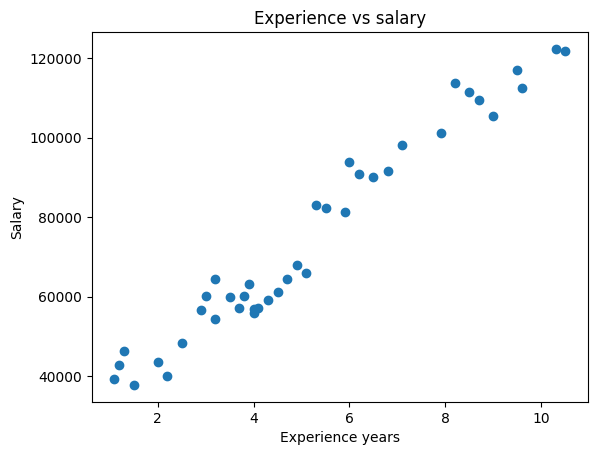

In [7]:
plt.scatter(df['Experience Years'],df['Salary'])
plt.xlabel('Experience years')
plt.ylabel('Salary')
plt.title('Experience vs salary')
plt.show()

In [8]:
X=df[['Experience Years']]
y=df['Salary']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
model = LinearRegression()

In [12]:
model.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred = model.predict(X_test)

In [14]:
print(y_pred)

[ 69052.39090243  64348.37526617  64348.37526617  83164.43781119
  45532.31272116  61525.96588442 117033.35039221  85046.04406569]


In [15]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head()

,Actual,Predicted
19,61111,69052.390902
16,56957,64348.375266
15,55794,64348.375266
26,93940,83164.437811
4,43525,45532.312721


In [16]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE =", mae)

MAE = 6419.911069460598


In [17]:
mse = mean_squared_error(y_test, y_pred)

print("MSE =", mse)

MSE = 48077731.16919359


In [18]:
r2 = r2_score(y_test, y_pred)

print("R2 Score =", r2)

R2 Score = 0.9068577573647874


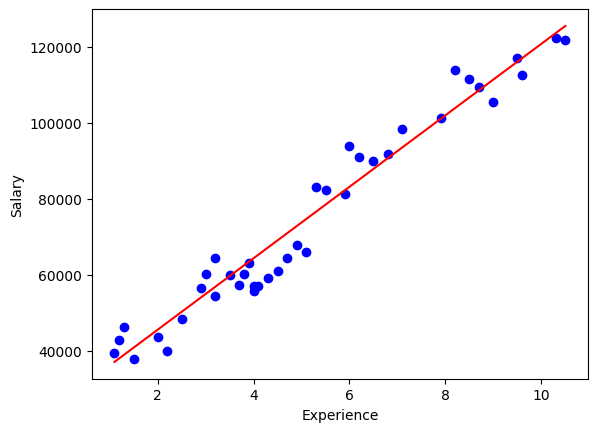

In [20]:
plt.scatter(X, y, color='blue')

plt.plot(
    X,
    model.predict(X),
    color='red'
)

plt.xlabel("Experience")
plt.ylabel("Salary")

plt.show()

In [22]:
experience = np.array([[10]])

salary = model.predict(experience)

print("Predicted Salary =", salary[0])

Predicted Salary = 120796.56290121133


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [23]:
print("Slope =", model.coef_)

print("Intercept =", model.intercept_)

Slope = [9408.03127251]
Intercept = 26716.250176145535
